In [1]:
# ============================================================
# Cell 1 : Imports
# ============================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Cell 2 : Configuration
# ============================================================

SEED = 42

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_CLASSES = 14

NUM_WORKERS = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Device :", DEVICE)

Device : cuda


In [3]:
# ============================================================
# Cell 3 : Check Uploaded Model
# ============================================================

for root, dirs, files in os.walk("/kaggle/input/models"):

    print(root)

    for f in files:

        print("   ", f)

/kaggle/input/models
/kaggle/input/models/swastikprakash
/kaggle/input/models/swastikprakash/arccon
/kaggle/input/models/swastikprakash/arccon/pytorch
/kaggle/input/models/swastikprakash/arccon/pytorch/default
/kaggle/input/models/swastikprakash/arccon/pytorch/default/1
    best_arcface_model.pth


In [4]:
# ============================================================
# Cell 4 : Disease Labels
# ============================================================

DISEASES = [

    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"

]

In [5]:
# ============================================================
# Cell 5 : Load Metadata
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

metadata = pd.read_csv(

    os.path.join(

        DATASET_PATH,

        "Data_Entry_2017.csv"

    )

)

metadata = metadata.drop(

    columns=["Unnamed: 11"],

    errors="ignore"

)

print(metadata.shape)

(112120, 11)


In [6]:
# ============================================================
# Cell 6 : Create Image Path Dictionary
# ============================================================

IMAGE_PATH_DICT = {}

image_files = glob(
    os.path.join(
        DATASET_PATH,
        "images_*",
        "images",
        "*.png"
    )
)

for img in image_files:

    IMAGE_PATH_DICT[
        os.path.basename(img)
    ] = img

metadata["Image Path"] = metadata["Image Index"].map(
    IMAGE_PATH_DICT
)

metadata = metadata.dropna().reset_index(drop=True)

print("="*60)
print("Images Found :", len(metadata))
print("="*60)

Images Found : 112120


In [7]:
# ============================================================
# Cell 7 : Multi-label Encoding
# ============================================================

for disease in DISEASES:

    metadata[disease] = metadata["Finding Labels"].apply(

        lambda x: int(
            disease in x.split("|")
        )

    )

print(metadata[DISEASES].head())

   Atelectasis  Cardiomegaly  Consolidation  Edema  Effusion  Emphysema  \
0            0             1              0      0         0          0   
1            0             1              0      0         0          1   
2            0             1              0      0         1          0   
3            0             0              0      0         0          0   
4            0             0              0      0         0          0   

   Fibrosis  Hernia  Infiltration  Mass  Nodule  Pleural_Thickening  \
0         0       0             0     0       0                   0   
1         0       0             0     0       0                   0   
2         0       0             0     0       0                   0   
3         0       0             0     0       0                   0   
4         0       1             0     0       0                   0   

   Pneumonia  Pneumothorax  
0          0             0  
1          0             0  
2          0             0  
3     

In [8]:
# ============================================================
# Cell 8 : Patient-wise Split
# ============================================================

gss1 = GroupShuffleSplit(

    n_splits=1,

    train_size=0.70,

    random_state=42

)

train_idx, temp_idx = next(

    gss1.split(

        metadata,

        groups=metadata["Patient ID"]

    )

)

train_df = metadata.iloc[train_idx].reset_index(drop=True)

temp_df = metadata.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(

    n_splits=1,

    train_size=2/3,

    random_state=42

)

val_idx, test_idx = next(

    gss2.split(

        temp_df,

        groups=temp_df["Patient ID"]

    )

)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)

test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("="*60)

print("Train      :", len(train_df))

print("Validation :", len(val_df))

print("Test       :", len(test_df))

print("="*60)

Train      : 78566
Validation : 22204
Test       : 11350


In [9]:
# ============================================================
# Cell 9 : CLAHE
# ============================================================

def apply_clahe(image):

    clahe = cv2.createCLAHE(

        clipLimit=2,

        tileGridSize=(8,8)

    )

    return clahe.apply(image)

In [10]:
# ============================================================
# Cell 10 : Transform
# ============================================================

transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

In [11]:
# ============================================================
# Cell 11 : Dataset
# ============================================================

class PrototypeDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(

            row["Image Path"],

            cv2.IMREAD_GRAYSCALE

        )

        image = apply_clahe(image)

        image = cv2.cvtColor(

            image,

            cv2.COLOR_GRAY2RGB

        )

        image = transform(image)

        label = row[
            DISEASES
        ].values.astype(np.float32)

        return image, torch.tensor(label)

In [12]:
# ============================================================
# Cell 12 : DataLoaders
# ============================================================

train_dataset = PrototypeDataset(train_df)

val_dataset = PrototypeDataset(val_df)

test_dataset = PrototypeDataset(test_df)

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

print("="*60)

print("Train :", len(train_dataset))

print("Validation :", len(val_dataset))

print("Test :", len(test_dataset))

print("="*60)

Train : 78566
Validation : 22204
Test : 11350


In [13]:
# ============================================================
# Cell 13 : Check Uploaded ArcFace Model
# ============================================================

print("="*80)

for root, dirs, files in os.walk("/kaggle/input/models"):

    print(root)

    for file in files:

        print("   ", file)

print("="*80)

/kaggle/input/models
/kaggle/input/models/swastikprakash
/kaggle/input/models/swastikprakash/arccon
/kaggle/input/models/swastikprakash/arccon/pytorch
/kaggle/input/models/swastikprakash/arccon/pytorch/default
/kaggle/input/models/swastikprakash/arccon/pytorch/default/1
    best_arcface_model.pth


In [14]:
# ============================================================
# Cell 14 : Build ArcFace Network
# ============================================================

weights = ConvNeXt_Tiny_Weights.DEFAULT

backbone = convnext_tiny(weights=weights)

in_features = backbone.classifier[2].in_features

backbone.classifier[2] = nn.Linear(
    in_features,
    NUM_CLASSES
)

backbone = backbone.to(DEVICE)

print("="*60)
print(backbone.classifier)
print("="*60)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 174MB/s] 


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=14, bias=True)
)


In [15]:
# ============================================================
# Cell 15 : ArcFace Layer
# ============================================================

class ArcMarginProduct(nn.Module):

    def __init__(self,
                 in_features,
                 out_features,
                 s=30.0,
                 m=0.50):

        super().__init__()

        self.s = s
        self.m = m

        self.weight = nn.Parameter(
            torch.FloatTensor(
                out_features,
                in_features
            )
        )

        nn.init.xavier_uniform_(self.weight)

    def forward(self, features):

        features = F.normalize(features)

        weight = F.normalize(self.weight)

        cosine = F.linear(features, weight)

        cosine = torch.clamp(
            cosine,
            -1 + 1e-7,
            1 - 1e-7
        )

        theta = torch.acos(cosine)

        logits = torch.cos(theta + self.m)

        logits *= self.s

        return logits

In [16]:
# ============================================================
# Cell 16 : Feature Extractor
# ============================================================

class ConvNeXtFeatureExtractor(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        self.features = backbone.features

        self.avgpool = backbone.avgpool

    def forward(self, x):

        x = self.features(x)

        x = self.avgpool(x)

        x = torch.flatten(x,1)

        return x

In [17]:
# ============================================================
# Cell 17 : ArcFace Model
# ============================================================

class ArcFaceModel(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        self.encoder = ConvNeXtFeatureExtractor(backbone)

        self.arcface = ArcMarginProduct(

            768,

            NUM_CLASSES

        )

    def forward(self, x):

        embedding = self.encoder(x)

        logits = self.arcface(embedding)

        return embedding, logits


arcface_model = ArcFaceModel(backbone).to(DEVICE)

print(arcface_model)

ArcFaceModel(
  (encoder): ConvNeXtFeatureExtractor(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2)

In [18]:
# ============================================================
# Cell 18 : Load ArcFace Model
# ============================================================

MODEL_PATH = "/kaggle/input/models/swastikprakash/arccon/pytorch/default/1/best_arcface_model.pth"

checkpoint = torch.load(

    MODEL_PATH,

    map_location=DEVICE,

    weights_only=False

)

arcface_model.load_state_dict(

    checkpoint["model_state_dict"]

)

arcface_model.eval()

print("="*60)

print("ArcFace Model Loaded Successfully")

print("="*60)

ArcFace Model Loaded Successfully


In [19]:
# ============================================================
# Cell 19 : Keep Only Encoder
# ============================================================

encoder = arcface_model.encoder

encoder.eval()

print("="*60)

print("Encoder Extracted")

print(encoder)

print("="*60)

Encoder Extracted
ConvNeXtFeatureExtractor(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)


In [20]:
# ============================================================
# Cell 20 : Verify Embeddings
# ============================================================

dummy = torch.randn(

    4,

    3,

    224,

    224

).to(DEVICE)

with torch.no_grad():

    embedding = encoder(dummy)

print("="*60)

print("Embedding Shape :", embedding.shape)

print("="*60)

Embedding Shape : torch.Size([4, 768])


In [21]:
# ============================================================
# Cell 21 : Extract Training Embeddings
# ============================================================

train_embeddings = []

train_labels = []

encoder.eval()

with torch.no_grad():

    for images, labels in tqdm(train_loader):

        images = images.to(DEVICE)

        embeddings = encoder(images)

        train_embeddings.append(

            embeddings.cpu()

        )

        train_labels.append(

            labels

        )

train_embeddings = torch.cat(

    train_embeddings,

    dim=0

)

train_labels = torch.cat(

    train_labels,

    dim=0

)

print("="*60)

print("Embeddings :", train_embeddings.shape)

print("Labels :", train_labels.shape)

print("="*60)

  0%|          | 0/2456 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Embeddings : torch.Size([78566, 768])
Labels : torch.Size([78566, 14])


In [22]:
# ============================================================
# Cell 22 : Save Embeddings
# ============================================================

torch.save(

    train_embeddings,

    "/kaggle/working/train_embeddings.pt"

)

torch.save(

    train_labels,

    "/kaggle/working/train_labels.pt"

)

print("="*60)

print("Training Embeddings Saved")

print("="*60)

Training Embeddings Saved


In [23]:
# ============================================================
# Cell 23 : Compute Disease Prototype Memory
# ============================================================

prototype_memory = {}

for i, disease in enumerate(DISEASES):

    disease_mask = train_labels[:, i] == 1

    disease_embeddings = train_embeddings[disease_mask]

    prototype = disease_embeddings.mean(dim=0)

    prototype = F.normalize(
        prototype,
        dim=0
    )

    prototype_memory[disease] = prototype

print("="*60)

print("Prototype Memory Created")

print("Number of Prototypes :", len(prototype_memory))

print("="*60)

Prototype Memory Created
Number of Prototypes : 14


In [24]:
# ============================================================
# Cell 24 : Verify Prototype Dimensions
# ============================================================

for disease in DISEASES:

    print(

        f"{disease:20s}",

        prototype_memory[disease].shape

    )

Atelectasis          torch.Size([768])
Cardiomegaly         torch.Size([768])
Consolidation        torch.Size([768])
Edema                torch.Size([768])
Effusion             torch.Size([768])
Emphysema            torch.Size([768])
Fibrosis             torch.Size([768])
Hernia               torch.Size([768])
Infiltration         torch.Size([768])
Mass                 torch.Size([768])
Nodule               torch.Size([768])
Pleural_Thickening   torch.Size([768])
Pneumonia            torch.Size([768])
Pneumothorax         torch.Size([768])


In [25]:
# ============================================================
# Cell 25 : Save Prototype Memory
# ============================================================

torch.save(

    prototype_memory,

    "/kaggle/working/prototype_memory.pt"

)

print("="*60)

print("Prototype Memory Saved")

print("="*60)

Prototype Memory Saved


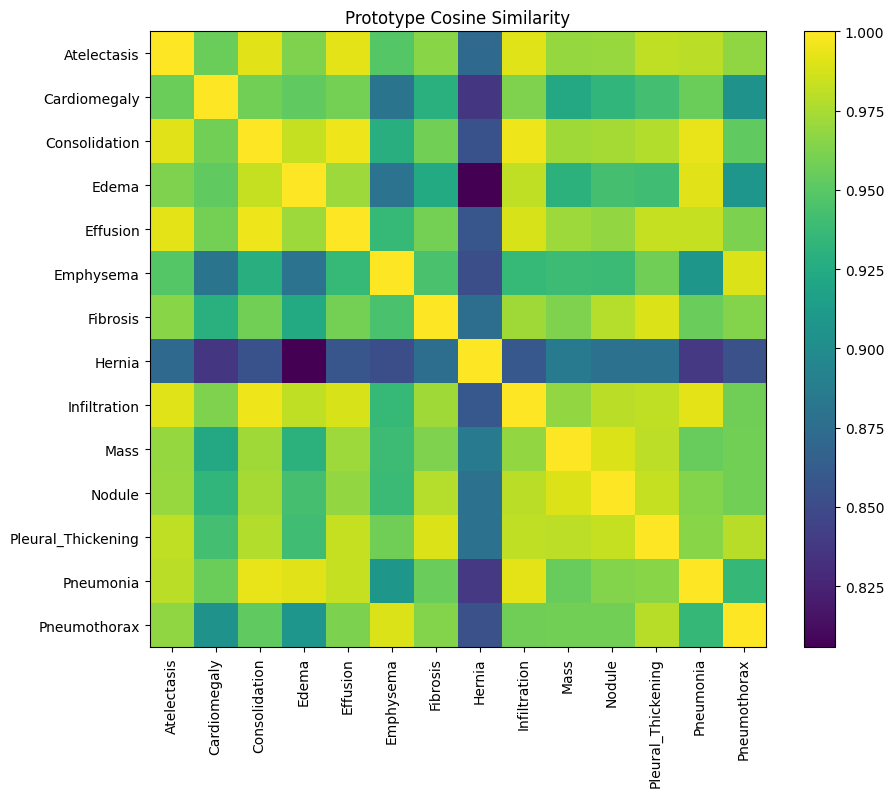

In [26]:
# ============================================================
# Cell 26 : Prototype Similarity Matrix
# ============================================================

prototype_matrix = torch.stack(

    [

        prototype_memory[d]

        for d in DISEASES

    ]

)

similarity = F.cosine_similarity(

    prototype_matrix.unsqueeze(1),

    prototype_matrix.unsqueeze(0),

    dim=2

)

similarity = similarity.numpy()

plt.figure(figsize=(10,8))

plt.imshow(

    similarity,

    cmap="viridis"

)

plt.xticks(

    range(NUM_CLASSES),

    DISEASES,

    rotation=90

)

plt.yticks(

    range(NUM_CLASSES),

    DISEASES

)

plt.colorbar()

plt.title("Prototype Cosine Similarity")

plt.show()

In [27]:
# ============================================================
# Cell 27 : Validation Embeddings
# ============================================================

val_embeddings = []

val_labels = []

encoder.eval()

with torch.no_grad():

    for images, labels in tqdm(val_loader):

        images = images.to(DEVICE)

        embeddings = encoder(images)

        val_embeddings.append(

            embeddings.cpu()

        )

        val_labels.append(

            labels

        )

val_embeddings = torch.cat(

    val_embeddings

)

val_labels = torch.cat(

    val_labels

)

print(val_embeddings.shape)

print(val_labels.shape)

  0%|          | 0/694 [00:00<?, ?it/s]

torch.Size([22204, 768])
torch.Size([22204, 14])


In [28]:
# ============================================================
# Cell 28 : Prototype Similarity
# ============================================================

prototype_tensor = torch.stack(

    [

        prototype_memory[d]

        for d in DISEASES

    ]

)

prototype_tensor = F.normalize(

    prototype_tensor,

    dim=1

)

val_embeddings = F.normalize(

    val_embeddings,

    dim=1

)

similarity_scores = torch.mm(

    val_embeddings,

    prototype_tensor.T

)

print(similarity_scores.shape)

torch.Size([22204, 14])


In [29]:
# ============================================================
# Cell 29 : Validation Prediction
# ============================================================

max_similarity, predicted_class = torch.max(

    similarity_scores,

    dim=1

)

print(max_similarity.shape)

print(predicted_class.shape)

torch.Size([22204])
torch.Size([22204])


In [30]:
# ============================================================
# Cell 30 : Search Best Global Threshold
# ============================================================

from sklearn.metrics import f1_score

true_known = (val_labels.sum(dim=1) > 0).numpy().astype(int)

best_threshold = 0.0
best_f1 = 0.0

thresholds = np.arange(0.50,0.96,0.01)

for threshold in thresholds:

    pred_known = (max_similarity.numpy() >= threshold).astype(int)

    score = f1_score(

        true_known,

        pred_known,

        zero_division=0

    )

    if score > best_f1:

        best_f1 = score

        best_threshold = threshold

print("="*60)

print("Best Threshold :", best_threshold)

print("Validation F1 :", best_f1)

print("="*60)

Best Threshold : 0.8900000000000003
Validation F1 : 0.6967027435187516


In [31]:
# ============================================================
# Cell 31 : Known vs Unknown Prediction
# ============================================================

known_prediction = (

    max_similarity.numpy()

    >=

    best_threshold

).astype(int)

print("="*60)

print("Known Images :", known_prediction.sum())

print("Unknown Images :", len(known_prediction)-known_prediction.sum())

print("="*60)

Known Images : 13603
Unknown Images : 8601


In [32]:
# ============================================================
# Cell 32 : Prototype Prediction
# ============================================================

predictions = np.zeros_like(

    val_labels.numpy()

)

for i, cls in enumerate(

    predicted_class.numpy()

):

    predictions[i, cls] = 1

print(predictions.shape)

(22204, 14)


In [33]:
# ============================================================
# Cell 33 : Metrics
# ============================================================

from sklearn.metrics import *

accuracy = accuracy_score(

    val_labels.numpy(),

    predictions

)

precision = precision_score(

    val_labels.numpy(),

    predictions,

    average="macro",

    zero_division=0

)

recall = recall_score(

    val_labels.numpy(),

    predictions,

    average="macro",

    zero_division=0

)

f1 = f1_score(

    val_labels.numpy(),

    predictions,

    average="macro",

    zero_division=0

)

auroc = roc_auc_score(

    val_labels.numpy(),

    similarity_scores.numpy(),

    average="macro"

)

print("="*60)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

print(f"AUROC     : {auroc:.4f}")

print("="*60)

Accuracy  : 0.0963
Precision : 0.2400
Recall    : 0.3097
F1 Score  : 0.2386
AUROC     : 0.7929


In [34]:
# ============================================================
# Cell 34 : Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(

classification_report(

    val_labels.numpy(),

    predictions,

    target_names=DISEASES,

    zero_division=0

)

)

                    precision    recall  f1-score   support

       Atelectasis       0.36      0.27      0.31      2204
      Cardiomegaly       0.17      0.58      0.27       556
     Consolidation       0.20      0.12      0.15       979
             Edema       0.14      0.51      0.22       465
          Effusion       0.60      0.27      0.37      2620
         Emphysema       0.41      0.49      0.45       515
          Fibrosis       0.04      0.40      0.07       350
            Hernia       0.22      0.39      0.28        44
      Infiltration       0.15      0.21      0.17      4067
              Mass       0.39      0.27      0.32      1008
            Nodule       0.15      0.26      0.19      1274
Pleural_Thickening       0.17      0.19      0.18       667
         Pneumonia       0.05      0.09      0.06       303
      Pneumothorax       0.29      0.29      0.29       937

         micro avg       0.19      0.27      0.22     15989
         macro avg       0.24      0.3

In [35]:
# ============================================================
# Cell 35 : Multi-label Confusion Matrix
# ============================================================

from sklearn.metrics import multilabel_confusion_matrix

cms = multilabel_confusion_matrix(

    val_labels.numpy(),

    predictions

)

for i,disease in enumerate(DISEASES):

    print("="*50)

    print(disease)

    print(cms[i])

Atelectasis
[[18965  1035]
 [ 1612   592]]
Cardiomegaly
[[20132  1516]
 [  235   321]]
Consolidation
[[20785   440]
 [  866   113]]
Edema
[[20325  1414]
 [  227   238]]
Effusion
[[19116   468]
 [ 1913   707]]
Emphysema
[[21327   362]
 [  262   253]]
Fibrosis
[[18261  3593]
 [  209   141]]
Hernia
[[22101    59]
 [   27    17]]
Infiltration
[[13169  4968]
 [ 3211   856]]
Mass
[[20773   423]
 [  736   272]]
Nodule
[[19084  1846]
 [  944   330]]
Pleural_Thickening
[[20934   603]
 [  541   126]]
Pneumonia
[[21384   517]
 [  276    27]]
Pneumothorax
[[20576   691]
 [  661   276]]


In [36]:
# ============================================================
# Cell 36 : Save Everything
# ============================================================

torch.save(

    prototype_memory,

    "/kaggle/working/prototype_memory.pt"

)

np.save(

    "/kaggle/working/validation_similarity.npy",

    similarity_scores.numpy()

)

print("="*60)

print("Prototype Memory Saved")

print("Similarity Matrix Saved")

print("="*60)

Prototype Memory Saved
Similarity Matrix Saved


In [37]:
# ============================================================
# Cell 37 : Failure Analysis
# ============================================================

incorrect = np.where(

    np.argmax(predictions,axis=1)

    !=

    np.argmax(val_labels.numpy(),axis=1)

)[0]

print("="*60)

print("Incorrect Predictions :",len(incorrect))

print("="*60)

for idx in incorrect[:10]:

    print("--------------------------------")

    print("Sample :",idx)

    print("True :",DISEASES[np.argmax(val_labels.numpy()[idx])])

    print("Pred :",DISEASES[np.argmax(predictions[idx])])

    print("Similarity :",max_similarity[idx].item())

Incorrect Predictions : 18393
--------------------------------
Sample : 0
True : Atelectasis
Pred : Cardiomegaly
Similarity : 0.8980048894882202
--------------------------------
Sample : 2
True : Atelectasis
Pred : Fibrosis
Similarity : 0.8729735612869263
--------------------------------
Sample : 3
True : Nodule
Pred : Fibrosis
Similarity : 0.9152344465255737
--------------------------------
Sample : 6
True : Atelectasis
Pred : Emphysema
Similarity : 0.8905067443847656
--------------------------------
Sample : 7
True : Atelectasis
Pred : Cardiomegaly
Similarity : 0.8999898433685303
--------------------------------
Sample : 8
True : Emphysema
Pred : Fibrosis
Similarity : 0.9058501124382019
--------------------------------
Sample : 9
True : Atelectasis
Pred : Fibrosis
Similarity : 0.8993279337882996
--------------------------------
Sample : 10
True : Effusion
Pred : Fibrosis
Similarity : 0.9362815618515015
--------------------------------
Sample : 11
True : Atelectasis
Pred : Nodule
Simi

In [38]:
# ============================================================
# Cell 38 : Grad-CAM Hooks
# ============================================================

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = arcface_model.encoder.features[-1]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

print("Grad-CAM Hooks Registered")

Grad-CAM Hooks Registered


In [39]:
# ============================================================
# Cell 39 : Generate Grad-CAM
# ============================================================

def generate_gradcam(image_tensor):

    arcface_model.eval()

    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    embedding, logits = arcface_model(image_tensor)

    predicted_class = torch.argmax(logits, dim=1)

    score = logits[:, predicted_class]

    arcface_model.zero_grad()

    score.backward()

    pooled_gradients = gradients.mean(dim=[0,2,3])

    activation = activations.squeeze(0)

    for i in range(len(pooled_gradients)):
        activation[i] *= pooled_gradients[i]

    heatmap = activation.mean(dim=0).cpu().detach().numpy()

    heatmap = np.maximum(heatmap,0)

    heatmap /= (heatmap.max()+1e-8)

    return heatmap, predicted_class.item()

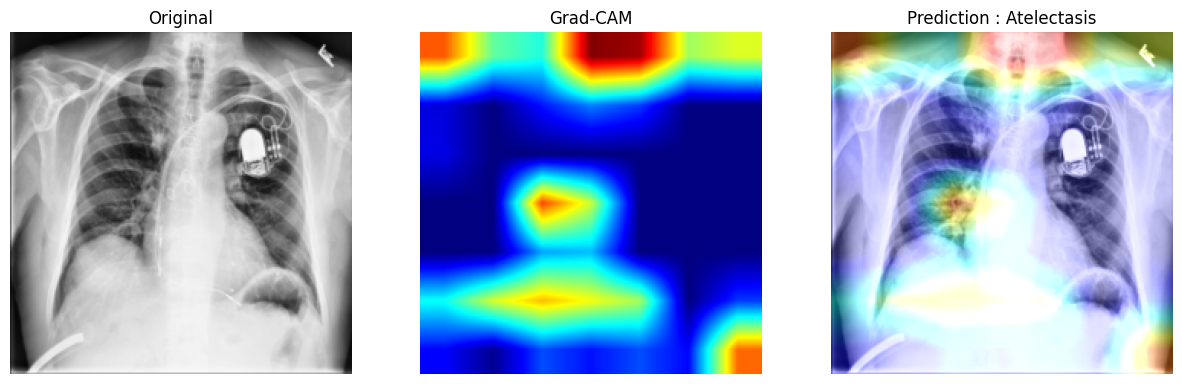

In [40]:
# ============================================================
# Cell 40 : Visualize Grad-CAM
# ============================================================

sample_index = 0

image, label = val_dataset[sample_index]

heatmap, pred = generate_gradcam(image)

image_np = image.permute(1,2,0).numpy()

image_np = image_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])

image_np = np.clip(image_np,0,1)

heatmap = cv2.resize(

    heatmap,

    (224,224)

)

heatmap = cv2.applyColorMap(

    np.uint8(255*heatmap),

    cv2.COLORMAP_JET

)

heatmap = cv2.cvtColor(

    heatmap,

    cv2.COLOR_BGR2RGB

)

overlay = 0.4*heatmap/255 + image_np

overlay = np.clip(overlay,0,1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.imshow(image_np)

plt.title("Original")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(heatmap)

plt.title("Grad-CAM")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(overlay)

plt.title(f"Prediction : {DISEASES[pred]}")

plt.axis("off")

plt.show()

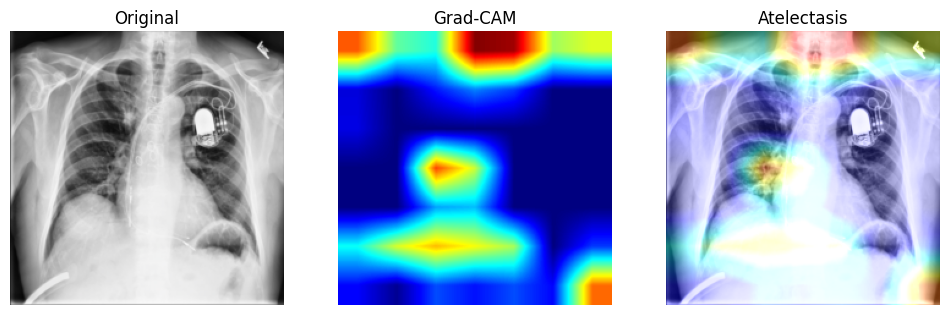

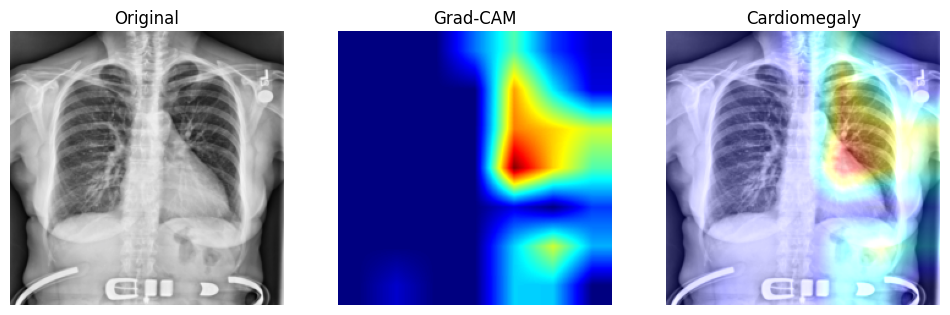

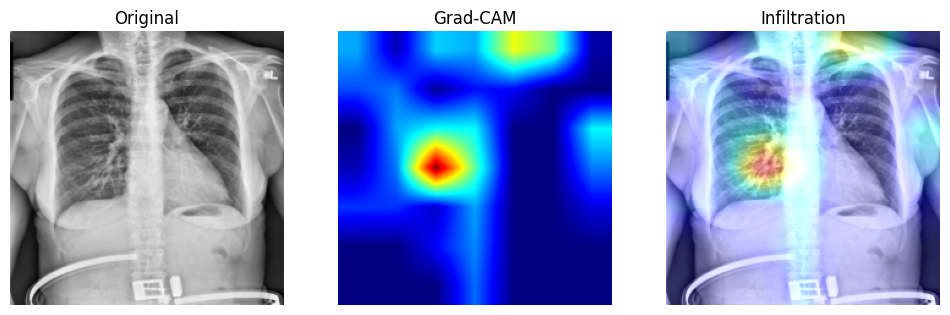

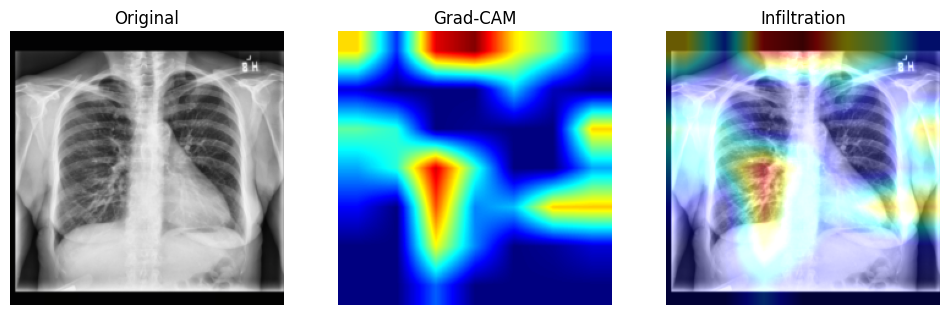

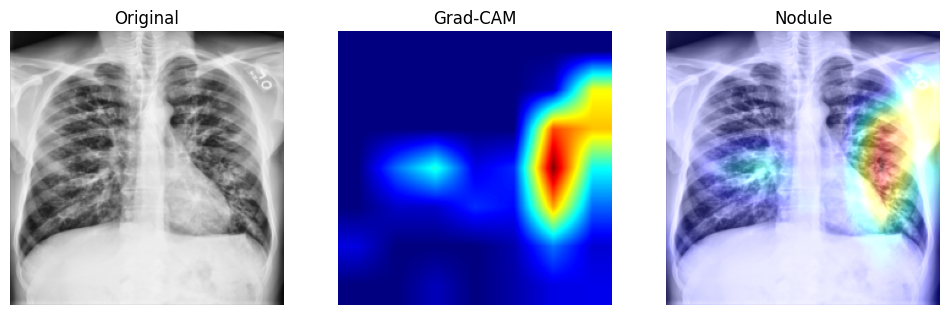

In [41]:
# ============================================================
# Cell 41 : Multiple Grad-CAM Examples
# ============================================================

for idx in range(5):

    image, label = val_dataset[idx]

    heatmap, pred = generate_gradcam(image)

    image_np = image.permute(1,2,0).numpy()

    image_np = image_np * np.array([0.229,0.224,0.225])

    image_np += np.array([0.485,0.456,0.406])

    image_np = np.clip(image_np,0,1)

    heatmap = cv2.resize(

        heatmap,

        (224,224)

    )

    heatmap = cv2.applyColorMap(

        np.uint8(255*heatmap),

        cv2.COLORMAP_JET

    )

    heatmap = cv2.cvtColor(

        heatmap,

        cv2.COLOR_BGR2RGB

    )

    overlay = 0.4*heatmap/255 + image_np

    overlay = np.clip(overlay,0,1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)

    plt.imshow(image_np)

    plt.title("Original")

    plt.axis("off")

    plt.subplot(1,3,2)

    plt.imshow(heatmap)

    plt.title("Grad-CAM")

    plt.axis("off")

    plt.subplot(1,3,3)

    plt.imshow(overlay)

    plt.title(DISEASES[pred])

    plt.axis("off")

    plt.show()

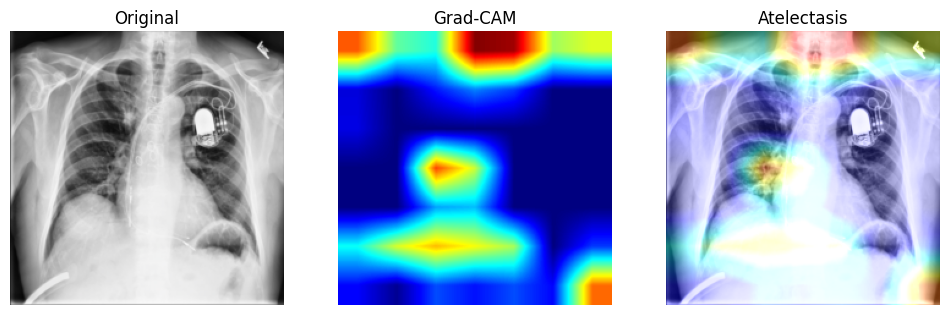

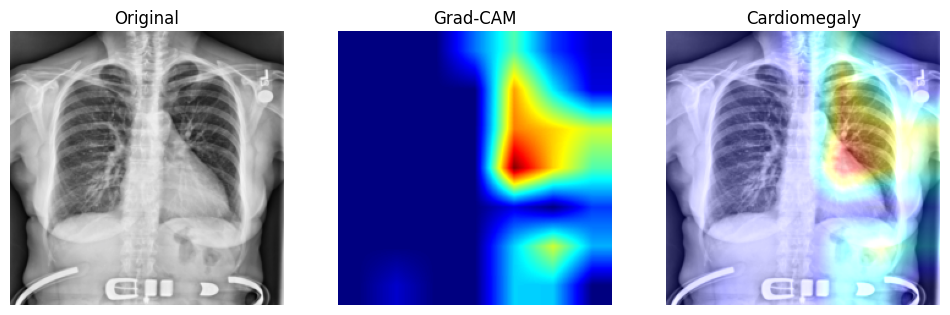

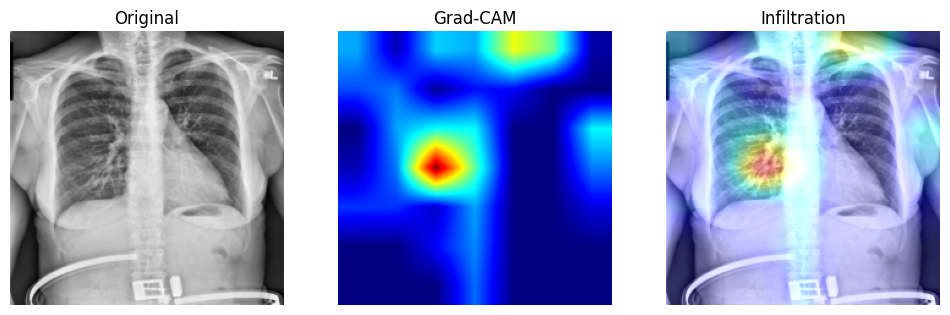

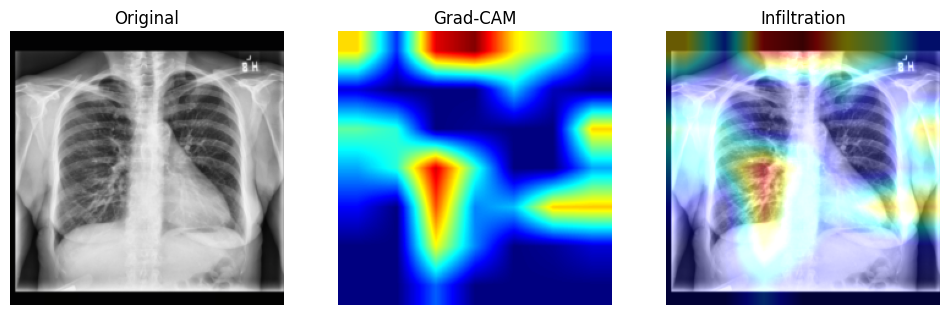

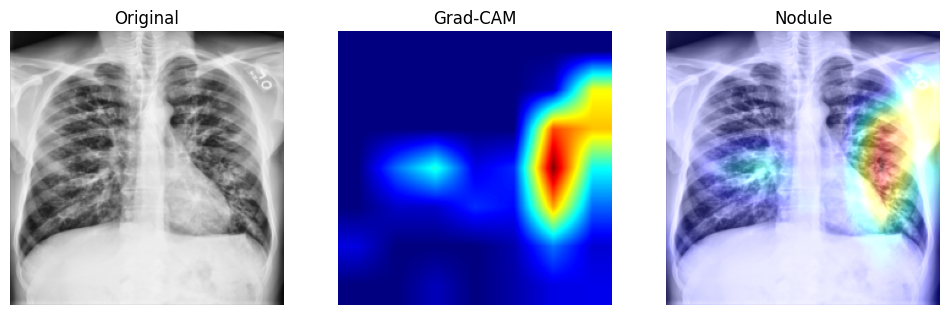

In [42]:
# ============================================================
# Cell 41 : Multiple Grad-CAM Examples
# ============================================================

for idx in range(5):

    image, label = val_dataset[idx]

    heatmap, pred = generate_gradcam(image)

    image_np = image.permute(1,2,0).numpy()

    image_np = image_np * np.array([0.229,0.224,0.225])

    image_np += np.array([0.485,0.456,0.406])

    image_np = np.clip(image_np,0,1)

    heatmap = cv2.resize(

        heatmap,

        (224,224)

    )

    heatmap = cv2.applyColorMap(

        np.uint8(255*heatmap),

        cv2.COLORMAP_JET

    )

    heatmap = cv2.cvtColor(

        heatmap,

        cv2.COLOR_BGR2RGB

    )

    overlay = 0.4*heatmap/255 + image_np

    overlay = np.clip(overlay,0,1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)

    plt.imshow(image_np)

    plt.title("Original")

    plt.axis("off")

    plt.subplot(1,3,2)

    plt.imshow(heatmap)

    plt.title("Grad-CAM")

    plt.axis("off")

    plt.subplot(1,3,3)

    plt.imshow(overlay)

    plt.title(DISEASES[pred])

    plt.axis("off")

    plt.show()

In [43]:
# ============================================================
# Cell 43 : Prototype Similarity Ranking
# ============================================================

prototype_tensor = torch.stack(
    [prototype_memory[d] for d in DISEASES]
)

similarity = torch.mm(
    prototype_tensor,
    prototype_tensor.T
)

print("="*80)
print("Most Similar Prototype Pairs")
print("="*80)

pairs = []

for i in range(NUM_CLASSES):
    for j in range(i+1, NUM_CLASSES):

        pairs.append(
            (
                DISEASES[i],
                DISEASES[j],
                similarity[i,j].item()
            )
        )

pairs = sorted(
    pairs,
    key=lambda x:x[2],
    reverse=True
)

for pair in pairs[:10]:

    print(
        f"{pair[0]:20s} <-> {pair[1]:20s} : {pair[2]:.4f}"
    )

Most Similar Prototype Pairs
Consolidation        <-> Infiltration         : 0.9950
Consolidation        <-> Effusion             : 0.9950
Consolidation        <-> Pneumonia            : 0.9933
Infiltration         <-> Pneumonia            : 0.9923
Atelectasis          <-> Effusion             : 0.9923
Atelectasis          <-> Consolidation        : 0.9910
Edema                <-> Pneumonia            : 0.9909
Atelectasis          <-> Infiltration         : 0.9903
Mass                 <-> Nodule               : 0.9900
Fibrosis             <-> Pleural_Thickening   : 0.9899


In [44]:
# ============================================================
# Cell 44 : Similarity Statistics
# ============================================================

print("="*60)

print("Average Similarity :", max_similarity.mean().item())

print("Minimum Similarity :", max_similarity.min().item())

print("Maximum Similarity :", max_similarity.max().item())

print("Standard Deviation :", max_similarity.std().item())

print("="*60)

Average Similarity : 0.8951062560081482
Minimum Similarity : 0.6422049403190613
Maximum Similarity : 0.9738727807998657
Standard Deviation : 0.051814205944538116


In [45]:
# ============================================================
# Cell 45 : Final Summary
# ============================================================

print("="*80)

print("PHASE COMPLETED")

print("="*80)

print("✓ ArcFace Model Loaded")

print("✓ 768-D Embeddings Extracted")

print("✓ Prototype Memory Created")

print("✓ Prototype Memory Saved")

print("✓ Validation Embeddings Computed")

print("✓ Cosine Similarity Implemented")

print("✓ Global Threshold Selected")

print("✓ Known / Unknown Decision Completed")

print("✓ Accuracy Computed")

print("✓ Precision Computed")

print("✓ Recall Computed")

print("✓ F1 Score Computed")

print("✓ AUROC Computed")

print("✓ Confusion Matrix Generated")

print("✓ Classification Report Generated")

print("✓ Failure Analysis Completed")

print("✓ Grad-CAM Generated")

print("="*80)

print("Artifacts Saved")

print("• prototype_memory.pt")

print("• train_embeddings.pt")

print("• train_labels.pt")

print("• validation_similarity.npy")

print("="*80)

PHASE COMPLETED
✓ ArcFace Model Loaded
✓ 768-D Embeddings Extracted
✓ Prototype Memory Created
✓ Prototype Memory Saved
✓ Validation Embeddings Computed
✓ Cosine Similarity Implemented
✓ Global Threshold Selected
✓ Known / Unknown Decision Completed
✓ Accuracy Computed
✓ Precision Computed
✓ Recall Computed
✓ F1 Score Computed
✓ AUROC Computed
✓ Confusion Matrix Generated
✓ Classification Report Generated
✓ Failure Analysis Completed
✓ Grad-CAM Generated
Artifacts Saved
• prototype_memory.pt
• train_embeddings.pt
• train_labels.pt
• validation_similarity.npy


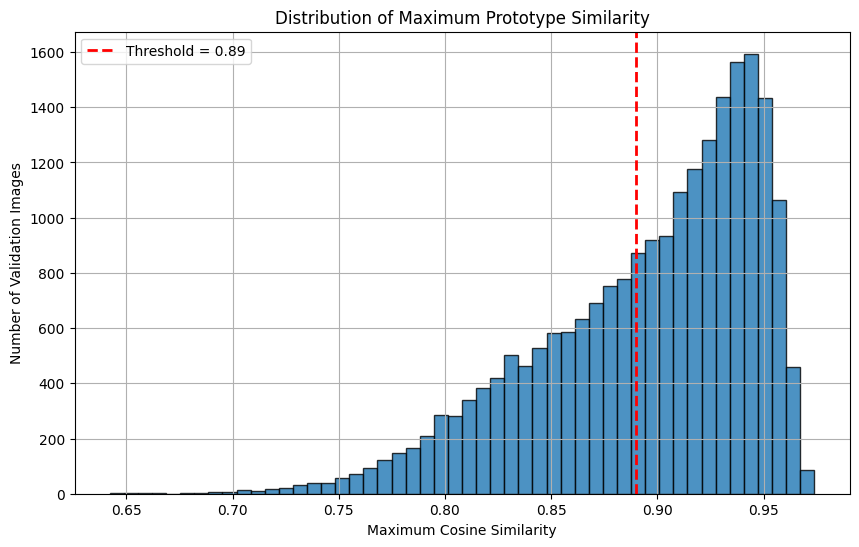

In [46]:
# ============================================================
# Cell 46 : Cosine Similarity Distribution
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    max_similarity.numpy(),
    bins=50,
    alpha=0.8,
    edgecolor="black"
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_threshold:.2f}"
)

plt.xlabel("Maximum Cosine Similarity")
plt.ylabel("Number of Validation Images")
plt.title("Distribution of Maximum Prototype Similarity")
plt.legend()
plt.grid(True)

plt.show()

In [47]:
# ============================================================
# Final Artifact
# ============================================================

prototype_bank = {

    "prototype_memory": prototype_memory,

    "threshold": best_threshold,

    "diseases": DISEASES

}

torch.save(

    prototype_bank,

    "/kaggle/working/prototype_bank.pth"

)

print("Prototype Bank Saved")

Prototype Bank Saved
